In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving sales_data.csv to sales_data.csv


In [ ]:
# Load the dataframe
df = pd.read_csv('sales_data.csv')

# Print data types of each column in the DataFrame
print(df.dtypes)

Order_ID        int64
Product        object
Category       object
Quantity        int64
Unit_Price      int64
Region         object
Month          object
Total_Sales     int64
dtype: object


In [ ]:
# Load the dataframe
df = pd.read_csv('sales_data.csv')

# Basic Information & Cleaning
print("\n🔹 Dataset Info:")
print(df.info())

print("\n🔹 Missing Values:")
print(df.isnull().sum())


🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_ID     50 non-null     int64 
 1   Product      50 non-null     object
 2   Category     50 non-null     object
 3   Quantity     50 non-null     int64 
 4   Unit_Price   50 non-null     int64 
 5   Region       50 non-null     object
 6   Month        50 non-null     object
 7   Total_Sales  50 non-null     int64 
dtypes: int64(4), object(4)
memory usage: 3.3+ KB
None

🔹 Missing Values:
Order_ID       0
Product        0
Category       0
Quantity       0
Unit_Price     0
Region         0
Month          0
Total_Sales    0
dtype: int64


In [ ]:
df.head(5)


,Order_ID,Product,Category,Quantity,Unit_Price,Region,Month,Total_Sales
0,1001,Printer,Furniture,3,3693,North,Apr,11079
1,1002,Headphones,Electronics,3,30467,West,Apr,91401
2,1003,Chair,Electronics,1,30723,North,Mar,30723
3,1004,Printer,Electronics,3,47699,East,Apr,143097
4,1005,Tablet,Electronics,5,4627,North,Mar,23135


In [ ]:
#See how many unique values each column contains
# Helps identify categorical vs numeric features and high-cardinality columns
df.nunique()

,0
Order_ID,50
Product,8
Category,2
Quantity,5
Unit_Price,50
Region,4
Month,6
Total_Sales,50


In [ ]:
#Descriptive Statistics
print("\n📊 Descriptive Statistics:")
print(df.describe())


📊 Descriptive Statistics:
         Order_ID   Quantity    Unit_Price    Total_Sales
count    50.00000  50.000000     50.000000      50.000000
mean   1025.50000   3.120000  28927.840000   93745.260000
std      14.57738   1.423419  17417.942874   79425.520246
min    1001.00000   1.000000   1663.000000    1663.000000
25%    1013.25000   2.000000  15085.500000   26078.000000
50%    1025.50000   3.000000  28636.000000   91085.000000
75%    1037.75000   4.000000  44931.750000  130076.500000
max    1050.00000   5.000000  59053.000000  295265.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
if 'Total_Sales' in df.columns:
    sales = df['Total_Sales']

    mean_val = np.mean(sales)
    median_val = np.median(sales)
    variance_val = np.var(sales, ddof=1)
    std_val = np.std(sales, ddof=1)

    print(f"\n📈 Mean Sales: {mean_val:.2f}")
    print(f"📈 Median Sales: {median_val:.2f}")
    print(f"📈 Variance: {variance_val:.2f}")
    print(f"📈 Standard Deviation: {std_val:.2f}")


📈 Mean Sales: 93745.26
📈 Median Sales: 91085.00
📈 Variance: 6308413266.32
📈 Standard Deviation: 79425.52


In [ ]:
# Outlier Detection in Sales Data using IQR Method
# Step 1: Select relevant numeric columns (ignore Order_ID)
numeric_columns = ['Quantity', 'Unit_Price', 'Total_Sales']

# Step 2: Collect indices of outliers using the IQR rule
outlier_indices = set()

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find and store outlier indices
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices.update(col_outliers)

    print(f"📊 {col}: Lower={lower_bound:.2f}, Upper={upper_bound:.2f}, Outliers={len(col_outliers)}")

# Step 3: Optionally, view the outlier rows
print("\n🔹 Outlier Rows:")
if outlier_indices:
    print(df.loc[list(outlier_indices)])
else:
    print("No outliers detected based on the IQR method.")

📊 Quantity: Lower=-1.00, Upper=7.00, Outliers=0
📊 Unit_Price: Lower=-29683.88, Upper=89701.12, Outliers=0
📊 Total_Sales: Lower=-129919.75, Upper=286074.25, Outliers=1

🔹 Outlier Rows:
    Order_ID  Product     Category  Quantity  Unit_Price Region Month  \
23      1024  Monitor  Electronics         5       59053   East   Feb   

    Total_Sales  
23       295265  


In [ ]:
# Step 4: Extract outlier rows and count
outlier_df = df.loc[list(outlier_indices)]
outlier_count = outlier_df.shape[0]

In [ ]:
# Step 5: Output summary
print("\n🚨 Number of outliers detected using 1.5×IQR method:", outlier_count)
print(f"Outliers detected across {len(numeric_columns)} columns: {numeric_columns}")


🚨 Number of outliers detected using 1.5×IQR method: 1
Outliers detected across 3 columns: ['Quantity', 'Unit_Price', 'Total_Sales']


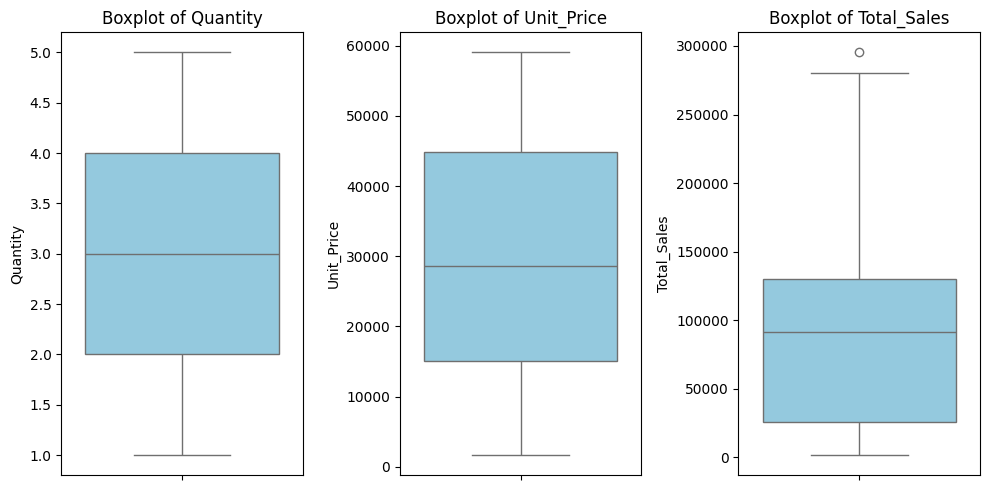

In [ ]:
# Visualize boxplots to confirm
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
for i, col in enumerate(numeric_columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

/tmp/ipython-input-269252465.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
/tmp/ipython-input-269252465.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
/tmp/ipython-input-269252465.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
/tmp/ipython-input-269252465.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

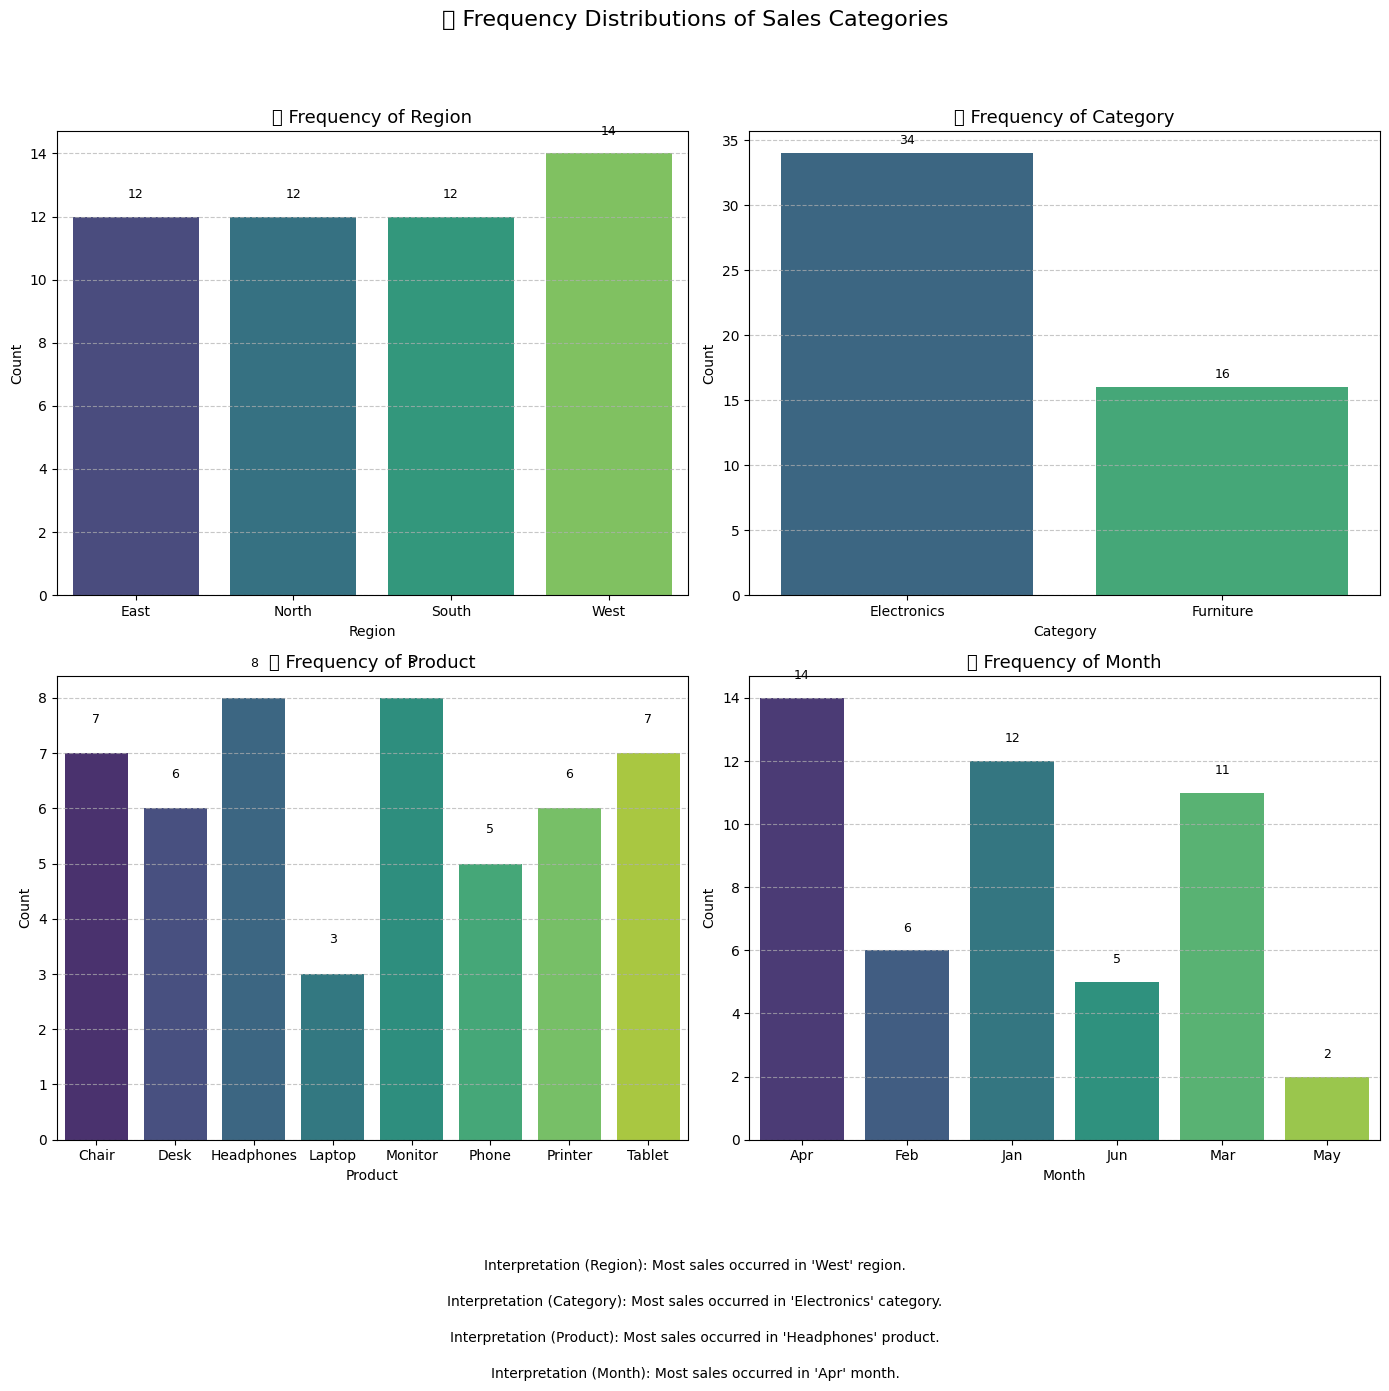

In [ ]:

# List of categorical columns in your sales dataset
categorical_columns = ['Region', 'Category', 'Product', 'Month']

#Set figure size and layout
plt.figure(figsize=(14, 12))

# Loop through each categorical column
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 2, i)  # 2x2 grid layout

    # Count frequencies
    value_counts = df[col].value_counts().sort_index()

    # Plot bar chart
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')

    # Add count labels
    for j, val in enumerate(value_counts.values):
        plt.text(j, val + 0.5, str(val), ha='center', va='bottom', fontsize=9)

    # Labels and titles
    plt.title(f"📊 Frequency of {col}", fontsize=13)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Mode interpretation
    mode_val = df[col].mode()[0]
    plt.figtext(
        0.5, -0.03 * i,
        f"Interpretation ({col}): Most sales occurred in '{mode_val}' {col.lower()}.",
        wrap=True, ha='center', fontsize=10
    )

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("🛒 Frequency Distributions of Sales Categories", fontsize=16, y=1.02)
plt.show()


📈 Numeric Columns Found: ['Order_ID', 'Quantity', 'Unit_Price', 'Total_Sales']
------------------------------------------------------------

🔹 Analyzing Column: Order_ID
------------------------------------------------------------


/tmp/ipython-input-2893576728.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


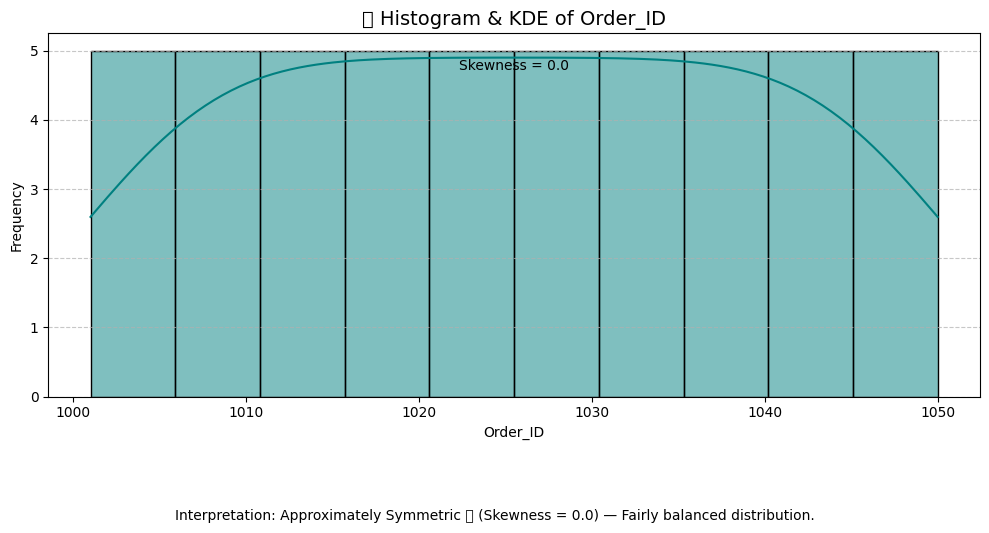

📦 Frequency Distribution of Order_ID:


,Bin Range,Frequency
0,1001.0 – 1005.9,5
1,1005.9 – 1010.8,5
2,1010.8 – 1015.7,5
3,1015.7 – 1020.6,5
4,1020.6 – 1025.5,5
5,1025.5 – 1030.4,5
6,1030.4 – 1035.3,5
7,1035.3 – 1040.2,5
8,1040.2 – 1045.1,5
9,1045.1 – 1050.0,5


📊 Summary Statistics for Order_ID:
Mean = 1025.50, Median = 1025.50, Variance = 212.50, Std Dev = 14.58

🔹 Analyzing Column: Quantity
------------------------------------------------------------


/tmp/ipython-input-2893576728.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


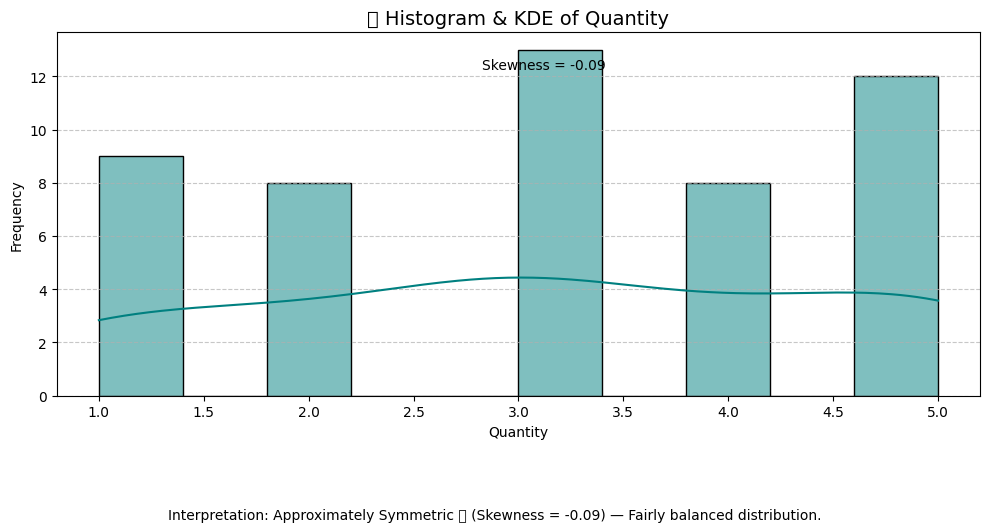

📦 Frequency Distribution of Quantity:


,Bin Range,Frequency
0,1.0 – 1.4,9
1,1.4 – 1.8,0
2,1.8 – 2.2,8
3,2.2 – 2.6,0
4,2.6 – 3.0,0
5,3.0 – 3.4,13
6,3.4 – 3.8,0
7,3.8 – 4.2,8
8,4.2 – 4.6,0
9,4.6 – 5.0,12


📊 Summary Statistics for Quantity:
Mean = 3.12, Median = 3.00, Variance = 2.03, Std Dev = 1.42

🔹 Analyzing Column: Unit_Price
------------------------------------------------------------


/tmp/ipython-input-2893576728.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


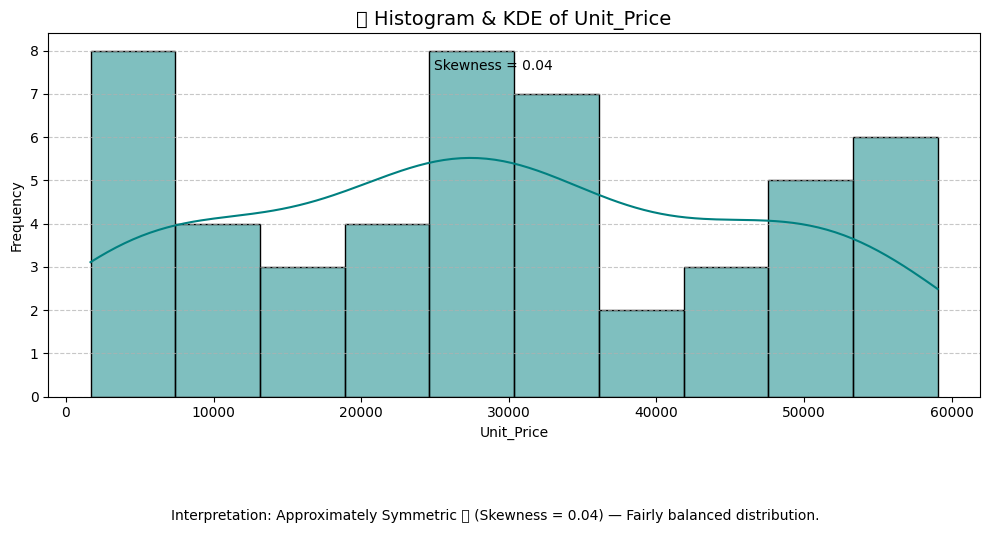

📦 Frequency Distribution of Unit_Price:


,Bin Range,Frequency
0,1663.0 – 7402.0,8
1,7402.0 – 13141.0,4
2,13141.0 – 18880.0,3
3,18880.0 – 24619.0,4
4,24619.0 – 30358.0,8
5,30358.0 – 36097.0,7
6,36097.0 – 41836.0,2
7,41836.0 – 47575.0,3
8,47575.0 – 53314.0,5
9,53314.0 – 59053.0,6


📊 Summary Statistics for Unit_Price:
Mean = 28927.84, Median = 28636.00, Variance = 303384733.97, Std Dev = 17417.94

🔹 Analyzing Column: Total_Sales
------------------------------------------------------------


/tmp/ipython-input-2893576728.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


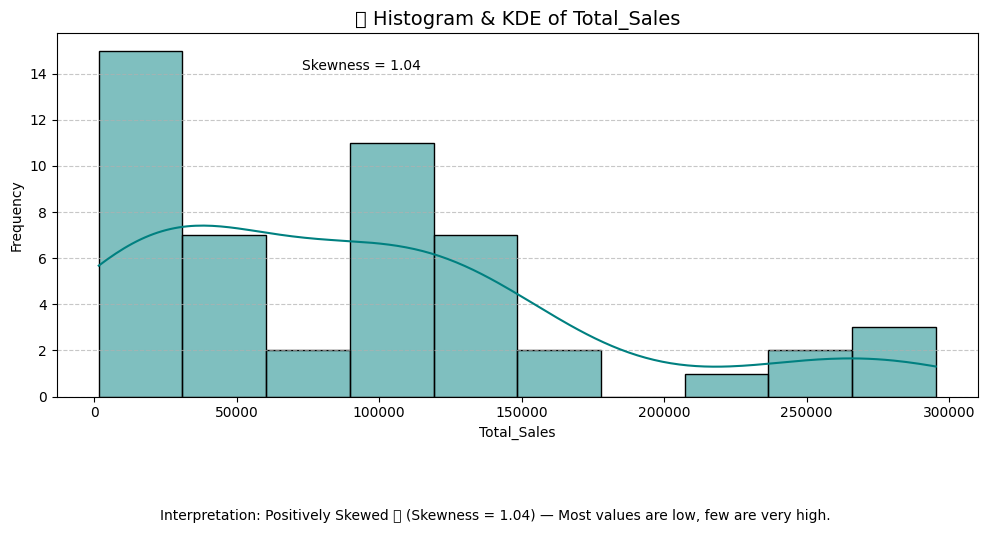

📦 Frequency Distribution of Total_Sales:


,Bin Range,Frequency
0,1663.0 – 31023.2,15
1,31023.2 – 60383.4,7
2,60383.4 – 89743.6,2
3,89743.6 – 119103.8,11
4,119103.8 – 148464.0,7
5,148464.0 – 177824.2,2
6,177824.2 – 207184.4,0
7,207184.4 – 236544.6,1
8,236544.6 – 265904.8,2
9,265904.8 – 295265.0,3


📊 Summary Statistics for Total_Sales:
Mean = 93745.26, Median = 91085.00, Variance = 6308413266.32, Std Dev = 79425.52


In [ ]:

# Statistical Distribution Analysis for All Numeric Columns
# Load your sales dataset
df = pd.read_csv("sales_data.csv")

# Identify numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("📈 Numeric Columns Found:", numeric_cols)
print("-" * 60)

# Loop through each numeric column for histogram + skewness analysis
for col in numeric_cols:
    print(f"\n🔹 Analyzing Column: {col}")
    print("-" * 60)

    # --- Histogram & KDE ---
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=10, kde=True, color='teal', edgecolor='black')

    # Titles and labels
    plt.title(f"📊 Histogram & KDE of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Skewness Calculation ---
    skew = df[col].skew()
    skew_val = round(skew, 2)

    # --- Interpretation ---
    if skew > 0.5:
        skew_type = f"Positively Skewed 📈 (Skewness = {skew_val}) — Most values are low, few are very high."
    elif skew < -0.5:
        skew_type = f"Negatively Skewed 📉 (Skewness = {skew_val}) — Most values are high, few are very low."
    else:
        skew_type = f"Approximately Symmetric ✅ (Skewness = {skew_val}) — Fairly balanced distribution."

    # Add skewness label on plot
    plt.text(x=df[col].mean(), y=plt.ylim()[1]*0.9,
             s=f"Skewness = {skew_val}", fontsize=10, ha='center')

    # Interpretation below the plot
    plt.figtext(0.5, -0.1, f"Interpretation: {skew_type}",
                wrap=True, ha='center', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- Frequency Table (Histogram Bins) ---
    counts, bin_edges = np.histogram(df[col].dropna(), bins=10)
    bin_labels = [f"{round(bin_edges[i], 2)} – {round(bin_edges[i+1], 2)}"
                  for i in range(len(counts))]
    bin_table = pd.DataFrame({
        'Bin Range': bin_labels,
        'Frequency': counts.astype(int)
    })

    print(f"📦 Frequency Distribution of {col}:")
    display(bin_table)

    # --- Summary Stats ---
    mean_val = df[col].mean()
    median_val = df[col].median()
    var_val = df[col].var()
    std_val = df[col].std()

    print(f"📊 Summary Statistics for {col}:")
    print(f"Mean = {mean_val:.2f}, Median = {median_val:.2f}, Variance = {var_val:.2f}, Std Dev = {std_val:.2f}")
    print("=" * 60)


📊 Categorical Columns to Analyze: ['Product', 'Category', 'Region', 'Month']
------------------------------------------------------------

🔹 Analyzing: Product vs Total_Sales
------------------------------------------------------------


/tmp/ipython-input-1618744741.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis')


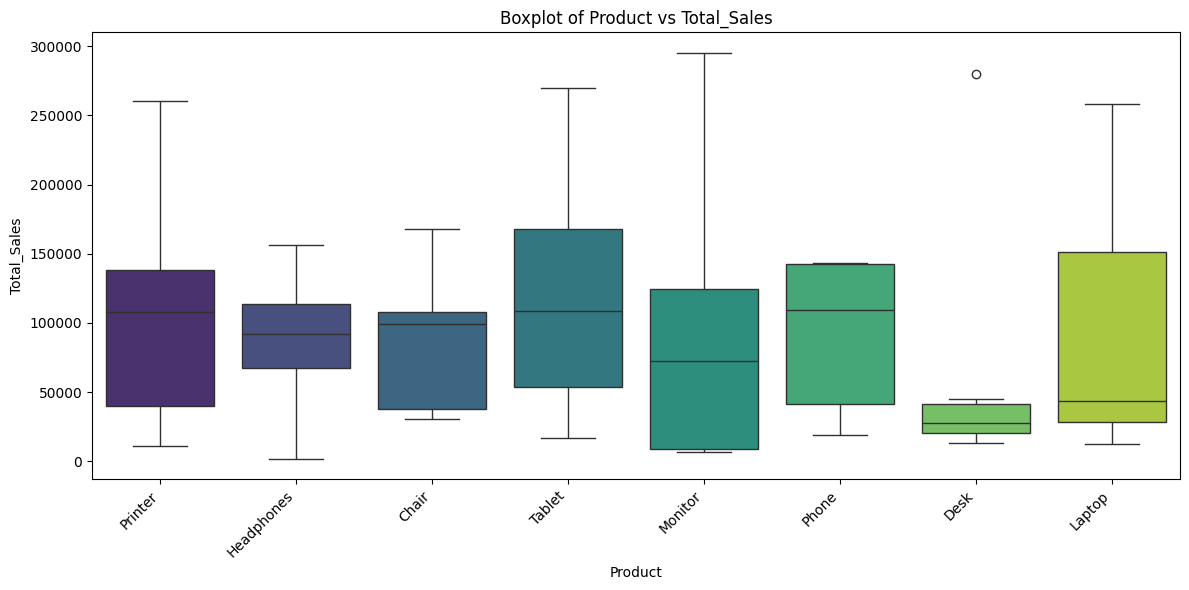


📊 Mean Total_Sales by Product:


,Total_Sales
Product,
Tablet,119858.000000
Printer,108781.166667
Laptop,104927.333333
Phone,91052.600000
Monitor,90126.500000
Headphones,87846.875000
Chair,84133.428571
Desk,68800.666667



🔹 Analyzing: Category vs Total_Sales
------------------------------------------------------------


/tmp/ipython-input-1618744741.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis')


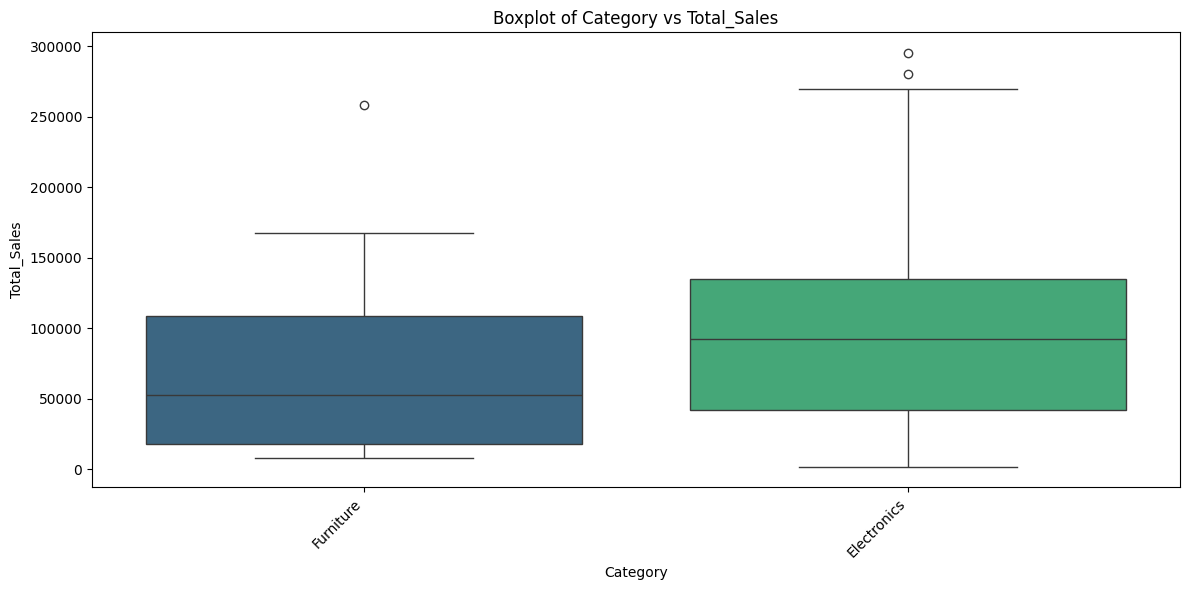


📊 Mean Total_Sales by Category:


,Total_Sales
Category,
Electronics,102714.294118
Furniture,74686.062500



🔹 Analyzing: Region vs Total_Sales
------------------------------------------------------------


/tmp/ipython-input-1618744741.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis')


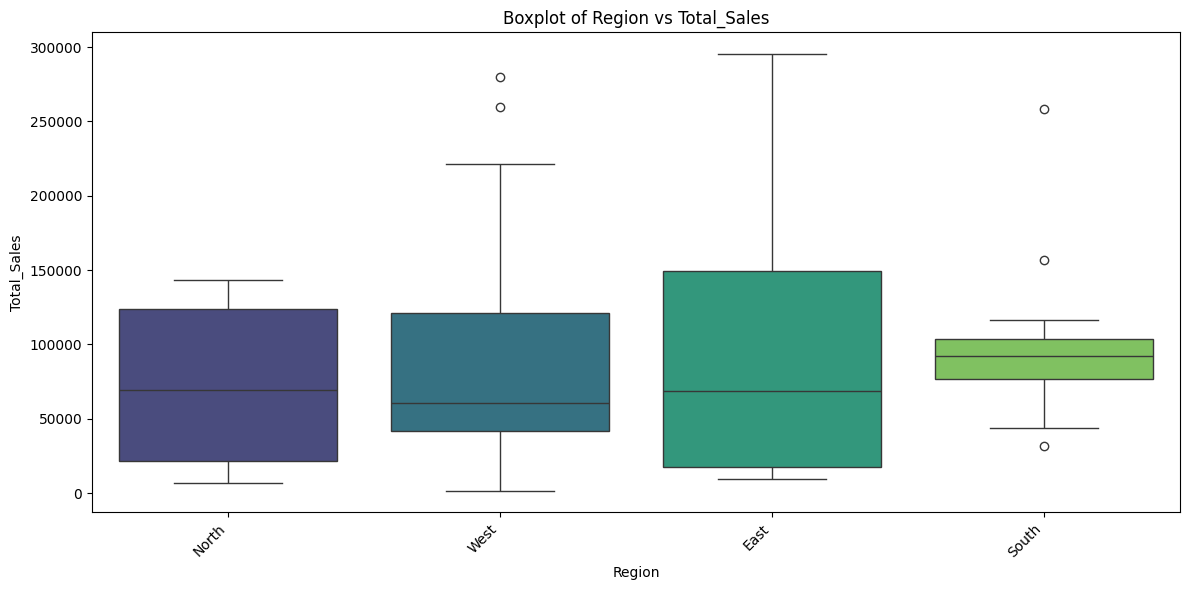


📊 Mean Total_Sales by Region:


,Total_Sales
Region,
East,101962.000000
South,101573.833333
West,97827.428571
North,72937.416667



🔹 Analyzing: Month vs Total_Sales
------------------------------------------------------------


/tmp/ipython-input-1618744741.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis')


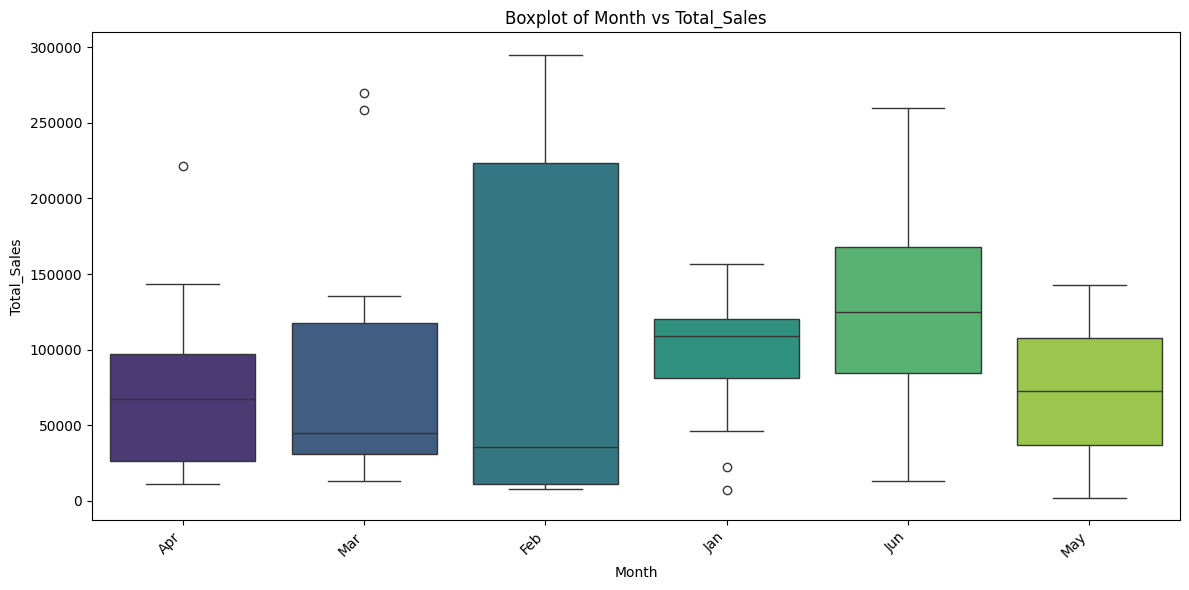


📊 Mean Total_Sales by Month:


,Total_Sales
Month,
Jun,130091.600000
Feb,110533.666667
Jan,96302.583333
Mar,93204.454545
Apr,74856.857143
May,72363.500000


In [ ]:
# Boxplot Analysis for All Categorical Columns vs Total Sales
# Define target (dependent) variable
target_col = 'Total_Sales'

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("📊 Categorical Columns to Analyze:", categorical_cols)
print("-" * 60)

# Loop through each categorical variable
for col in categorical_cols:
    print(f"\n🔹 Analyzing: {col} vs {target_col}")
    print("-" * 60)

    # Skip columns with too many unique categories (for readability)
    if df[col].nunique() > 15:
        print(f"⚠️ Skipping {col} — too many categories for clear visualization.\n")
        continue

    # Create boxplot for categorical variable vs Total Sales
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, y=target_col, data=df, palette='viridis')
    plt.title(f'Boxplot of {col} vs {target_col}')
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.tight_layout()
    plt.show()

    # Optional: Print mean sales per category
    mean_sales_per_category = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f"\n📊 Mean {target_col} by {col}:")
    display(mean_sales_per_category)
    print("=" * 60)

/tmp/ipython-input-1545253647.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Quantity_Bin', y=target_col, data=df, palette='coolwarm', showfliers=False)
/tmp/ipython-input-1545253647.py:31: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


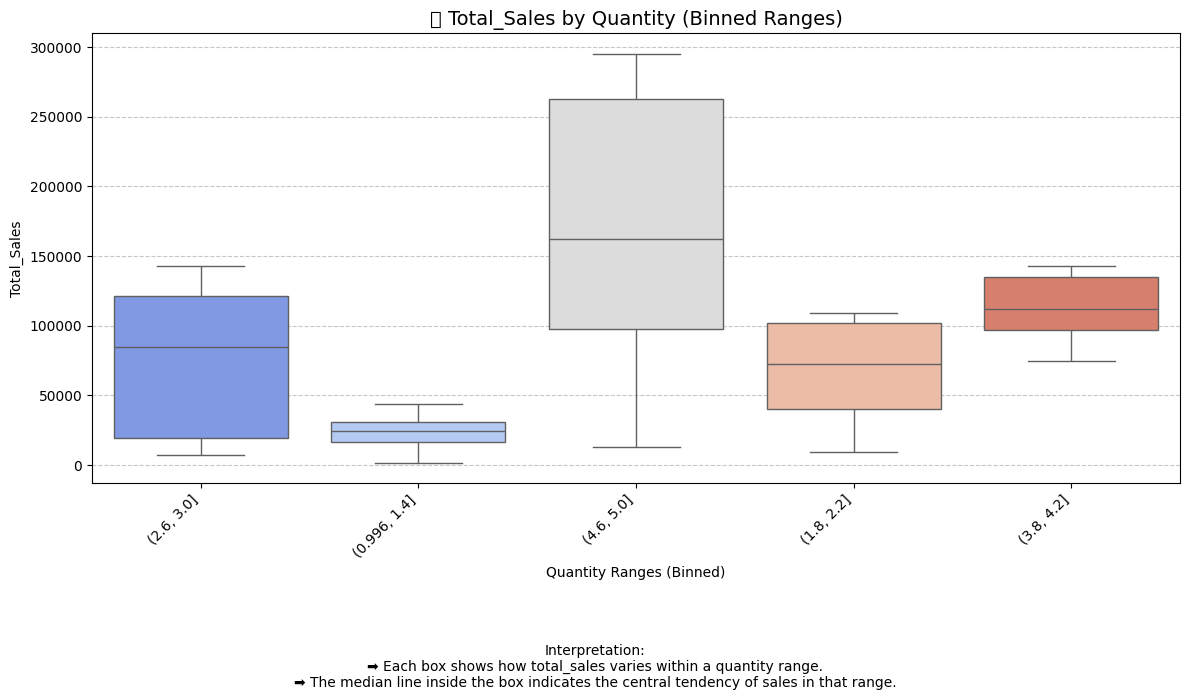

In [ ]:
# Boxplot of Total Sales by Quantity (Binned Ranges)
# Define variables
col = 'Quantity'        # Numeric independent variable
target_col = 'Total_Sales'  # Dependent variable

# Bin Quantity into 10 equal-width ranges
df['Quantity_Bin'] = pd.cut(df[col], bins=10).astype(str)

# Create boxplot of Total Sales by Quantity bins
plt.figure(figsize=(12, 6))
sns.boxplot(x='Quantity_Bin', y=target_col, data=df, palette='coolwarm', showfliers=False)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Titles and labels
plt.title(f"📦 {target_col} by {col} (Binned Ranges)", fontsize=14)
plt.xlabel(f"{col} Ranges (Binned)")
plt.ylabel(target_col)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Teaching-style interpretation
plt.figtext(
    0.5, -0.15,
    f"Interpretation:\n"
    f"➡️ Each box shows how {target_col.lower()} varies within a {col.lower()} range.\n"
    f"➡️ The median line inside the box indicates the central tendency of sales in that range.",
    wrap=True, ha='center', fontsize=10
)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


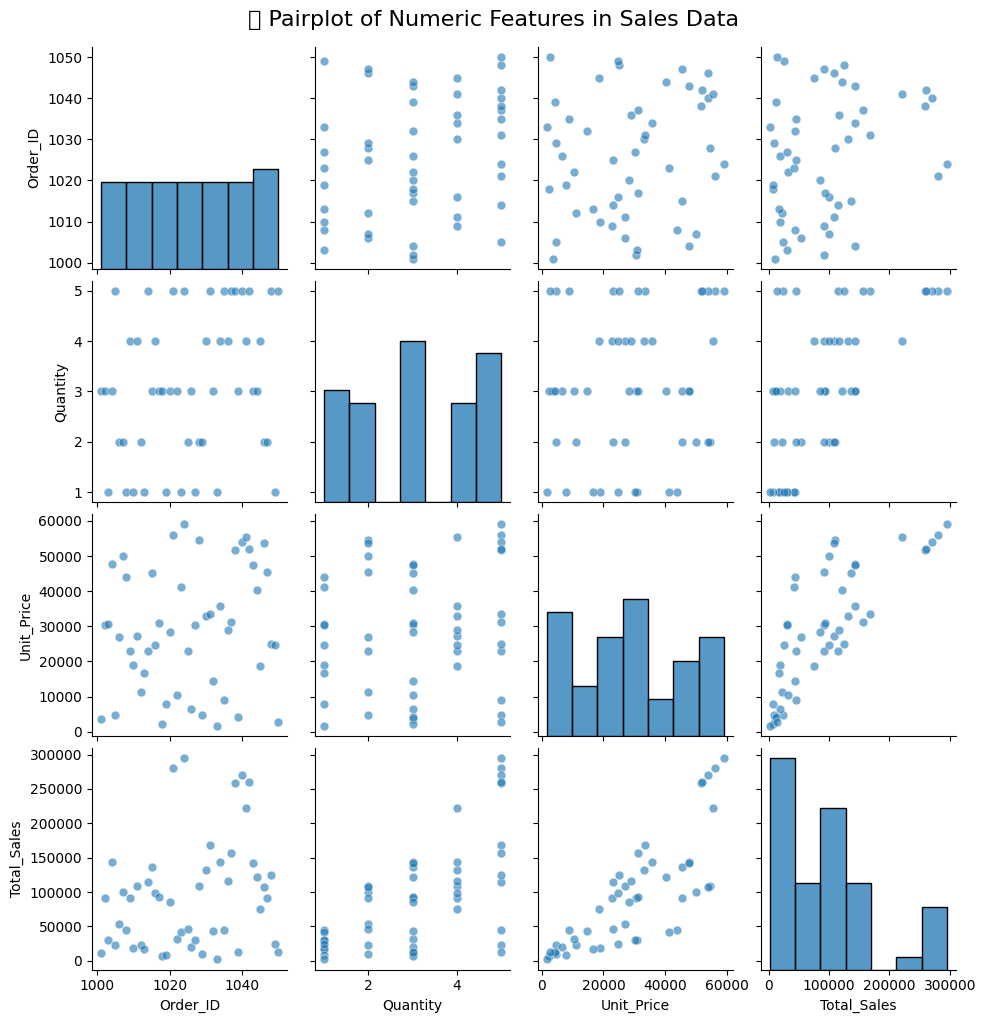

In [ ]:
# PART 1️ — Pairplot for Numeric Features

if len(numeric_cols) > 1:
    sns.pairplot(df[numeric_cols], diag_kind='hist', plot_kws={'alpha': 0.6, 's': 40})
    plt.suptitle("🔍 Pairplot of Numeric Features in Sales Data", fontsize=16, y=1.02)
    plt.show()
else:
    print("⚠️ Not enough numeric columns for pairplot.")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


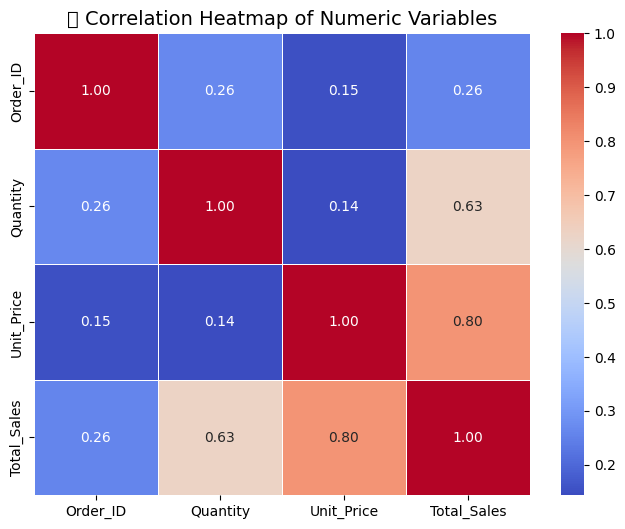

In [ ]:
# PART 2️ — Correlation Heatmap for Numeric Columns
# ============================================================
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("🔥 Correlation Heatmap of Numeric Variables", fontsize=14)
plt.show()

/tmp/ipython-input-2016076605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis', showfliers=False)
/tmp/ipython-input-2016076605.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


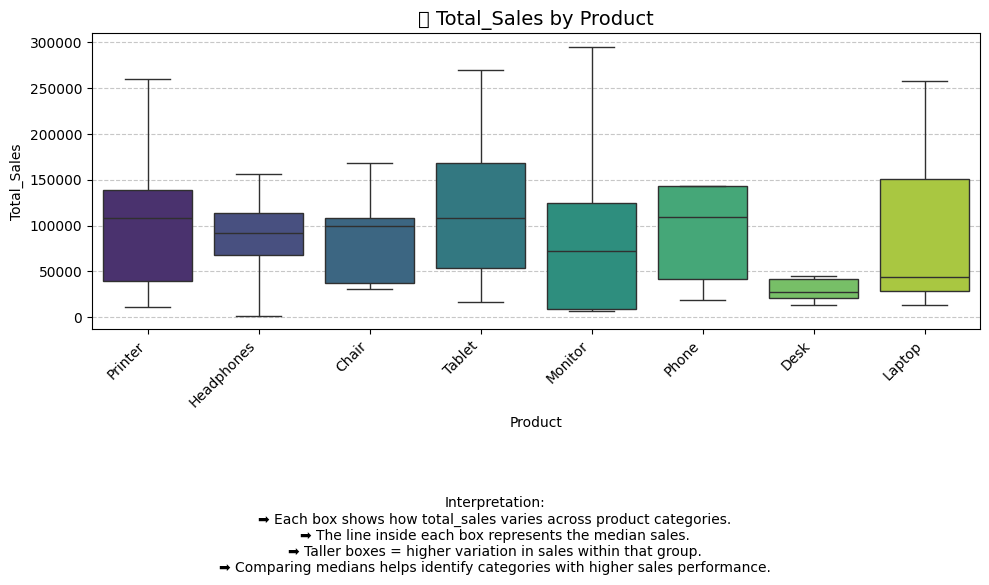

/tmp/ipython-input-2016076605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis', showfliers=False)
/tmp/ipython-input-2016076605.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


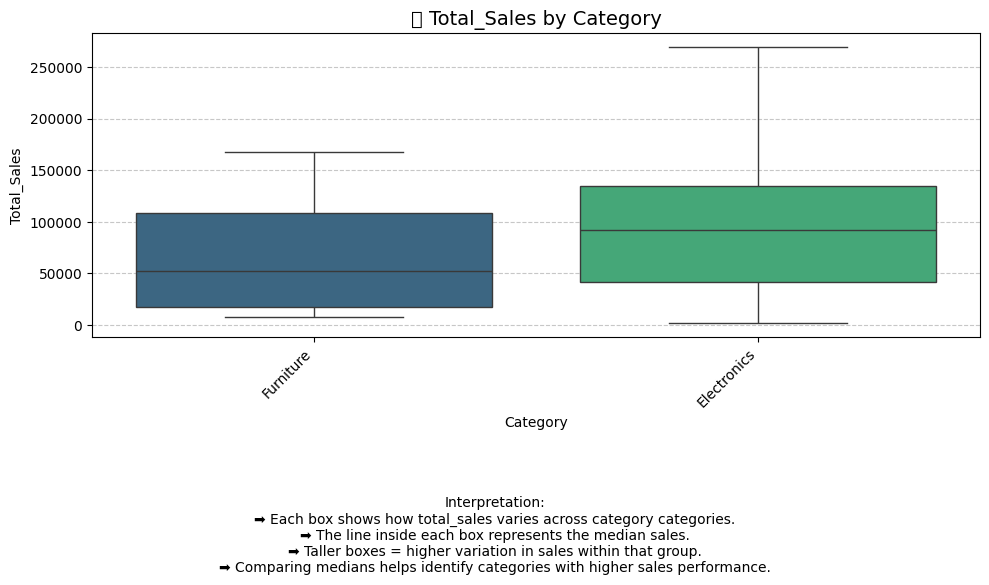

/tmp/ipython-input-2016076605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis', showfliers=False)
/tmp/ipython-input-2016076605.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


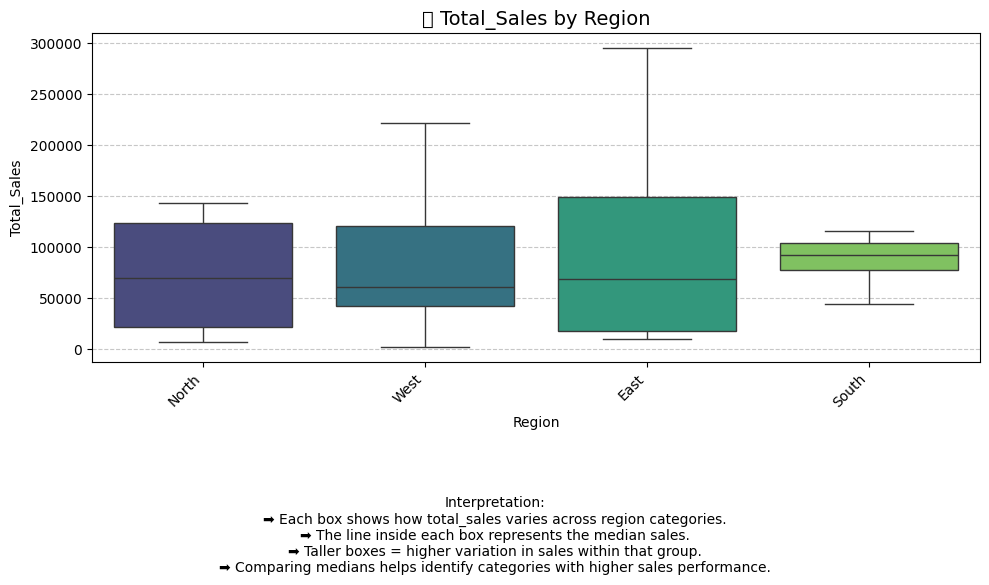

/tmp/ipython-input-2016076605.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_col, data=df, palette='viridis', showfliers=False)
/tmp/ipython-input-2016076605.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.1, 1, 1])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


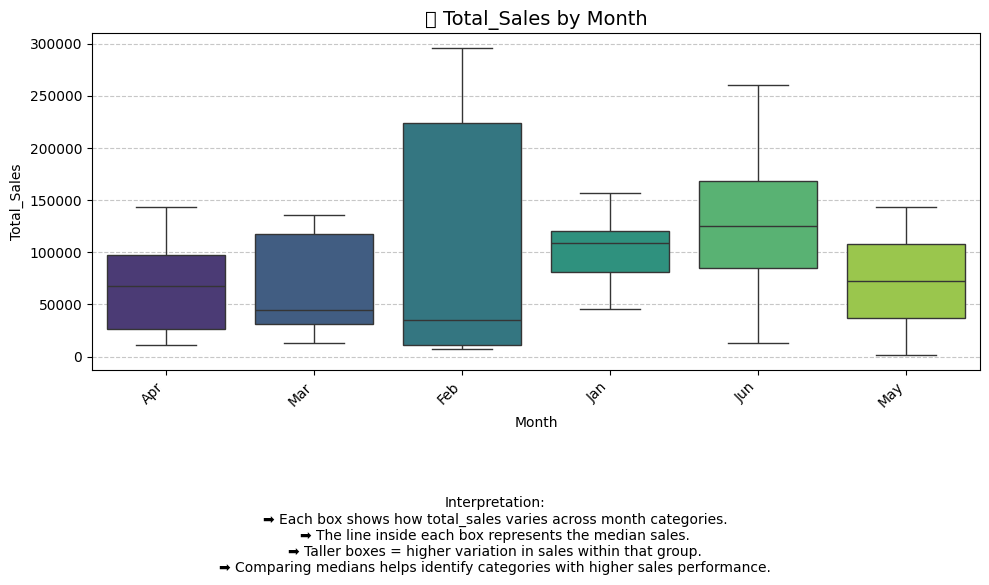

In [ ]:
# Only proceed if Total_Sales exists in the dataset
if target_col in df.columns:
    for col in categorical_cols:
        # Skip columns with too many unique values
        if df[col].nunique() > 12:
            continue

        plt.figure(figsize=(10, 5))
        sns.boxplot(x=col, y=target_col, data=df, palette='viridis', showfliers=False)
        plt.xticks(rotation=45, ha='right')
        plt.title(f"💰 {target_col} by {col}", fontsize=14)
        plt.xlabel(col)
        plt.ylabel(target_col)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Interpretation below plot
        plt.figtext(
            0.5, -0.15,
            f"Interpretation:\n"
            f"➡️ Each box shows how {target_col.lower()} varies across {col.lower()} categories.\n"
            f"➡️ The line inside each box represents the median sales.\n"
            f"➡️ Taller boxes = higher variation in sales within that group.\n"
            f"➡️ Comparing medians helps identify categories with higher sales performance.",
            wrap=True, ha='center', fontsize=10
        )

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()
else:
    print("⚠️ 'Total_Sales' column not found in the dataset.")

In [ ]:
# One-Hot Encode Categorical Columns in Sales Dataset
# Identify categorical (object or string) columns automatically
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("🏷️ Categorical columns to be encoded:", categorical_cols)

# One-hot encode all categorical columns
# Why?
# - ML models need numeric input.
# - Converts each category into binary features (0/1).
# - drop_first=True prevents multicollinearity (baseline category dropped).
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display updated dataframe
print("\n✅ One-hot encoding complete! Sample output:")
print(df.head())

# Optional: Check new column names
print("\n📊 New columns after encoding:")
print(df.columns.tolist())


🏷️ Categorical columns to be encoded: ['Product', 'Category', 'Region', 'Month', 'Quantity_Bin']

✅ One-hot encoding complete! Sample output:
   Order_ID  Quantity  Unit_Price  Total_Sales  Product_Desk  \
0      1001         3        3693        11079         False   
1      1002         3       30467        91401         False   
2      1003         1       30723        30723         False   
3      1004         3       47699       143097         False   
4      1005         5        4627        23135         False   

   Product_Headphones  Product_Laptop  Product_Monitor  Product_Phone  \
0               False           False            False          False   
1                True           False            False          False   
2               False           False            False          False   
3               False           False            False          False   
4               False           False            False          False   

   Product_Printer  ...  Region_We

In [ ]:
# 🔹 Step 3: Scale numeric features using StandardScaler

# Why?
# - Sales data often has features with different scales (e.g., Quantity in units, Sales in ₹).
# - StandardScaler transforms each feature to mean = 0 and std = 1.
# - Prevents features with large ranges from dominating model training.
from sklearn.preprocessing import StandardScaler

# Identify numeric columns
# Automatically detect numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("📊 Numeric columns detected for scaling:", numeric_cols)

# Make a copy of original data for comparison (optional)
df_original = df.copy()

# Initialize scaler
scaler = StandardScaler()

# Fit and transform numeric columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Display summary statistics post-scaling
print("\n✅ Scaled numeric feature summary:")
print(df[numeric_cols].describe())

# ✅ Optional: Show before & after comparison for a sample column
sample_col = numeric_cols[0]
comparison = pd.DataFrame({
    'Before Scaling': df_original[sample_col],
    'After Scaling': df[sample_col]
})
print(f"\n🔍 Example scaling effect on '{sample_col}':")
print(comparison.head())


📊 Numeric columns detected for scaling: ['Order_ID', 'Quantity', 'Unit_Price', 'Total_Sales']

✅ Scaled numeric feature summary:
        Order_ID      Quantity    Unit_Price   Total_Sales
count  50.000000  5.000000e+01  5.000000e+01  5.000000e+01
mean    0.000000 -7.993606e-17 -2.664535e-17  7.105427e-17
std     1.010153  1.010153e+00  1.010153e+00  1.010153e+00
min    -1.697749 -1.504492e+00 -1.581223e+00 -1.171124e+00
25%    -0.848875 -7.948261e-01 -8.027857e-01 -8.606082e-01
50%     0.000000 -8.515994e-02 -1.692524e-02 -3.383382e-02
75%     0.848875  6.245063e-01  9.281458e-01  4.620693e-01
max     1.697749  1.334172e+00  1.747107e+00  2.562976e+00

🔍 Example scaling effect on 'Order_ID':
   Before Scaling  After Scaling
0            1001      -1.697749
1            1002      -1.628453
2            1003      -1.559158
3            1004      -1.489862
4            1005      -1.420566


In [ ]:
# Step 4: Separate input features (X) and target variable (y)

# Why?
# - In supervised learning, we must separate the independent (X) and dependent (y) variables.
# - Here, 'Total_Sales' is the target we aim to predict using other columns.
# - We drop columns that aren't useful for regression (like IDs or binned variables).

# Choose target variable
target_col = 'Total_Sales'

# Drop target and irrelevant columns (if any exist)
# Examples: Transaction_ID, Date, or previously binned columns
columns_to_drop = ['Order_ID', 'Quantity_Bin'] # Add 'Quantity_Bin' to columns to drop

# Drop columns safely (only if present)
X = df.drop(columns=[c for c in columns_to_drop + [target_col] if c in df.columns], axis=1)
y = df[target_col]

# Display dataset shapes
print("✅ Features shape:", X.shape)
print("🎯 Target shape:", y.shape)

# Optional: Show first few feature and target samples
print("\n🔍 Feature sample:")
print(X.head())

print("\n🎯 Target sample:")
print(y.head())

✅ Features shape: (50, 22)
🎯 Target shape: (50,)

🔍 Feature sample:
   Quantity  Unit_Price  Product_Desk  Product_Headphones  Product_Laptop  \
0 -0.085160   -1.463493         False               False           False   
1 -0.085160    0.089263         False                True           False   
2 -1.504492    0.104110         False               False           False   
3 -0.085160    1.088632         False               False           False   
4  1.334172   -1.409326         False               False           False   

   Product_Monitor  Product_Phone  Product_Printer  Product_Tablet  \
0            False          False             True           False   
1            False          False            False           False   
2            False          False            False           False   
3            False          False             True           False   
4            False          False            False            True   

   Category_Furniture  ...  Region_West  Month_F

In [ ]:
# Step 6: Import necessary libraries for Linear Regression and evaluation
# Why?
# - We need the LinearRegression class to build the model.
# - Evaluation metrics (Mean Absolute Error, Mean Squared Error, R2 Score) help us assess performance.
# - These metrics give insights on prediction accuracy and model fit.

#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# ------------------------------------------------------------
# 🔹 Step 6 (Preprocessing): Encode Categorical Features
# ------------------------------------------------------------
# Why?
# - Linear Regression requires numeric input.
# - One-Hot Encoding creates binary columns (0/1) for each category.
# - drop_first=True avoids dummy variable trap (multicollinearity).
# ------------------------------------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Identify categorical and numeric columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🧩 Categorical columns:", cat_cols)
print("📊 Numeric columns:", num_cols)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ✅ Define target and features
target_col = 'Total_Sales'  # or 'Profit', depending on your goal
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# ✅ Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Initialize and train the model
sales_model = LinearRegression()
sales_model.fit(X_train, y_train)

print("✅ Model training complete — all categorical columns encoded successfully.")


🧩 Categorical columns: []
📊 Numeric columns: ['Order_ID', 'Quantity', 'Unit_Price', 'Total_Sales']
✅ Model training complete — all categorical columns encoded successfully.


In [ ]:
# Step 9: Evaluate model using common regression metrics
# Why?
# - Mean Absolute Error (MAE) measures average absolute prediction error (lower is better).
# - Mean Squared Error (MSE) penalizes larger errors more (lower is better).
# - R2 Score indicates proportion of variance explained (closer to 1 is better).

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = sales_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance on Test Set:\n"
      f"MAE: {mae:.2f}\n"
      f"MSE: {mse:.2f}\n"
      f"R2 Score: {r2:.4f}")

Model Performance on Test Set:
MAE: 0.32
MSE: 0.14
R2 Score: 0.8724


In [ ]:
# Step 10: Examine model coefficients to understand feature impact
# Why?
# - Coefficients represent the effect of each feature on predicted Price.
# - Positive coefficient means increasing feature value increases Price.
# - Negative coefficient means increasing feature value decreases Price.
# - Helps interpret which features drive laptop prices.

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': sales_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Model Coefficients:\n", coefficients)

Model Coefficients:
                     Feature  Coefficient
2                Unit_Price     0.769556
14                Month_Feb     0.576493
1                  Quantity     0.476832
18                Month_May     0.425364
22  Quantity_Bin_(4.6, 5.0]     0.189255
5            Product_Laptop     0.174063
10       Category_Furniture     0.113187
8           Product_Printer     0.087099
15                Month_Jan     0.081668
0                  Order_ID     0.051258
20  Quantity_Bin_(2.6, 3.0]     0.034099
21  Quantity_Bin_(3.8, 4.2]     0.008433
13              Region_West    -0.011279
4        Product_Headphones    -0.083504
11             Region_North    -0.128149
12             Region_South    -0.155476
9            Product_Tablet    -0.169182
17                Month_Mar    -0.174344
19  Quantity_Bin_(1.8, 2.2]    -0.178606
6           Product_Monitor    -0.200562
16                Month_Jun    -0.311172
7             Product_Phone    -0.394892
3              Product_Desk    -0.47

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


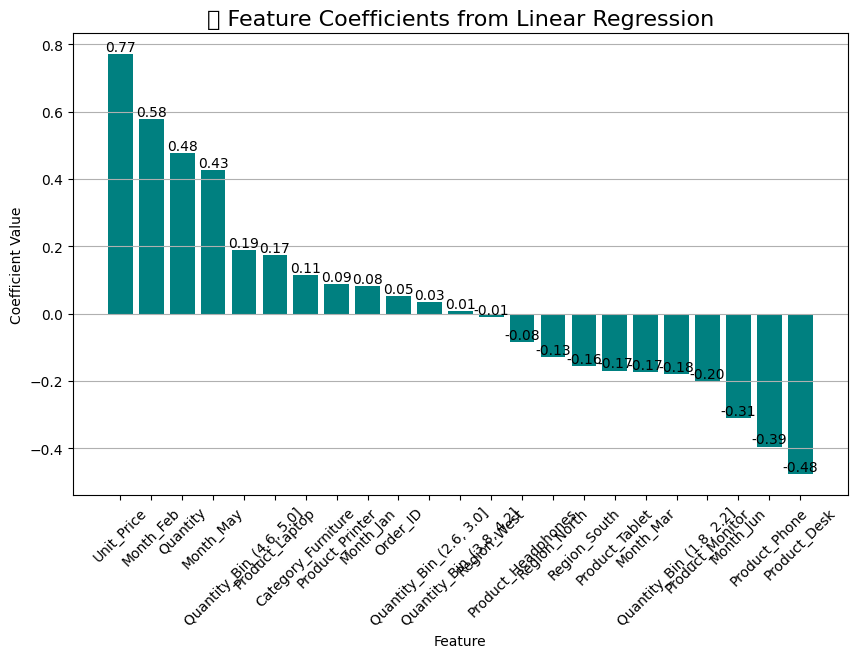

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare DataFrame of features and coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': sales_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(coefficients['Feature'], coefficients['Coefficient'], color='teal')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('📊 Feature Coefficients from Linear Regression', fontsize=16)
plt.ylabel('Coefficient Value')
plt.xlabel('Feature')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-1610095542.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


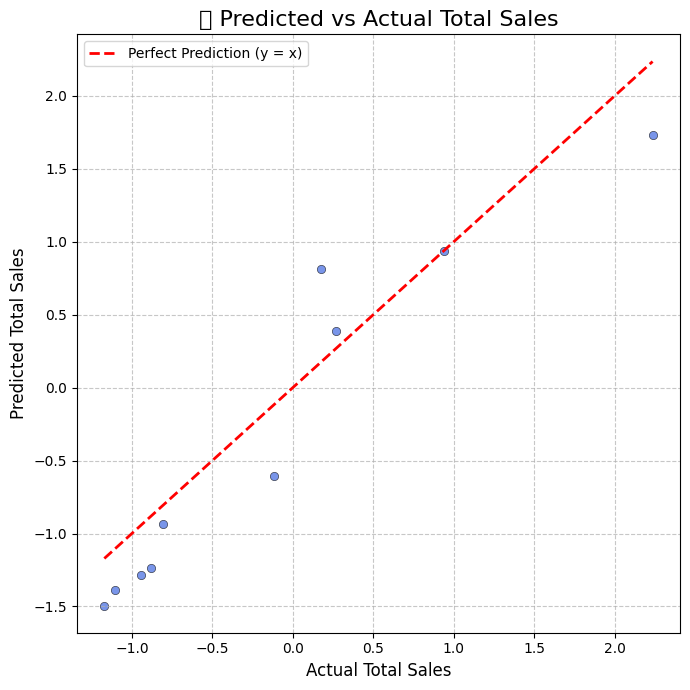

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 🔹 Step 11: Plot Predicted vs Actual Total Sales
# ------------------------------------------------------------
# Why?
# - Helps visually assess prediction accuracy.
# - Points near the red diagonal (y = x) indicate good predictions.
# - Wide scatter away from the line means higher prediction errors.
# - Complements numeric metrics like R², MAE, and RMSE.
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='royalblue', edgecolor='k')

# ✅ Add diagonal line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction (y = x)'
)

# ✅ Customize titles and labels
plt.title("📈 Predicted vs Actual Total Sales", fontsize=16)
plt.xlabel("Actual Total Sales", fontsize=12)
plt.ylabel("Predicted Total Sales", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


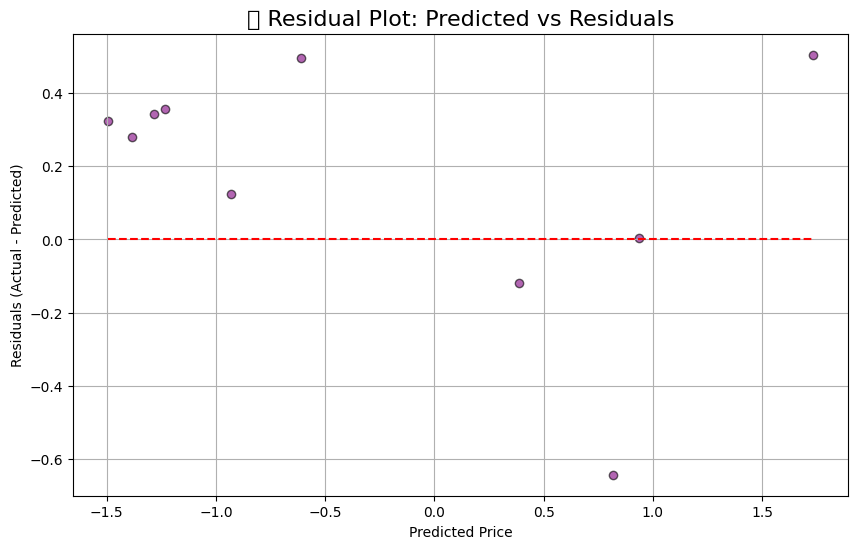

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 12: Calculate residuals (errors)
# Residual = Actual - Predicted
residuals = y_test - y_pred

# Create residual plot: Residuals vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, edgecolor='k', color='purple')

# Horizontal line at zero residual (ideal)
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red', linestyles='dashed')

plt.title("📉 Residual Plot: Predicted vs Residuals", fontsize=16)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True)
plt.show()


In [ ]:
# Evaluate on training set
y_train_pred = sales_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluate on testing set
test_r2 = r2_score(y_test, y_pred)

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")

Train R2: 0.9697
Test R2: 0.8724


In [ ]:
#Probability & Distribution Insights
# Example: Probability that sales > mean
prob_above_mean = np.mean(sales > mean_val)
print(f"\n🎯 Probability that Sales > Mean: {prob_above_mean:.2%}")


🎯 Probability that Sales > Mean: 44.00%


In [ ]:
# t-test against hypothetical mean (₹80,000)
t_stat, p_val = stats.ttest_1samp(sales, 80000)
print("\n🔹 One Sample t-Test for Total Sales vs ₹80,000:")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")
if p_val < 0.05:
    print("✅ Significant difference from ₹80,000 (Reject H0)")
else:
    print("❌ No significant difference (Fail to reject H0)")


🔹 One Sample t-Test for Total Sales vs ₹80,000:
t-statistic = 1.224, p-value = 0.2269
❌ No significant difference (Fail to reject H0)


In [ ]:
# Confidence Interval
conf_int = stats.t.interval(
    0.95, len(sales)-1, loc=np.mean(sales), scale=stats.sem(sales)
)
print(f"\n📏 95% Confidence Interval for Mean Total Sales: {conf_int}")


📏 95% Confidence Interval for Mean Total Sales: (np.float64(71172.7769000262), np.float64(116317.74309997378))


In [ ]:
# Drop Order_ID (since it's unique and not categorical info)
# df = df.drop(columns=['Order_ID'], errors='ignore') # Order_ID was already dropped and scaled

# Identify categorical columns
# cat_cols = df.select_dtypes(include=['object', 'category']).columns

# If any numeric column is categorical encoded (like 0/1), you can manually add them:
# cat_cols = cat_cols.tolist() + ['Some_Numeric_Categorical_Column']

# print(f"Categorical Columns: {list(cat_cols)}\n")

# Perform Chi-square test for each categorical column vs target
# Choose your target variable here (example: 'Product_Category' or 'Region')
# target = 'Category'  # Change this to your actual target column

# chi_results = []

# for col in cat_cols:
#     if col != target:  # skip target itself
#         contingency = pd.crosstab(df[col], df[target])
#         chi2, p, dof, ex = chi2_contingency(contingency)
#         chi_results.append({
#             'Feature': col,
#             'Chi2 Statistic': chi2,
#             'p-value': p,
#             'Dependent?': 'Yes' if p < 0.05 else 'No'
#         })

# Convert results to DataFrame
# chi_df = pd.DataFrame(chi_results).sort_values(by='p-value')

# print("\n📊 Chi-Square Test Results:\n")
# print(chi_df)

In [ ]:
# ---------------------------------------------------------
# 📊 Chi-Square Test for Categorical Columns in Sales Data
# ---------------------------------------------------------

import pandas as pd
from scipy.stats import chi2_contingency

# Load your dataset
df = pd.read_csv("sales_data.csv")

# Drop ID or unique columns
df = df.drop(columns=["Order_ID"], errors="ignore")

# Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Optional: specify a target column to test association with (e.g., 'Region')
target_col = "Region"   # Change this to 'Category' or another column if desired

# Perform Chi-Square test for each categorical column (except the target)
chi_square_results = []

for col in cat_cols:
    if col == target_col:
        continue  # skip the target itself

    contingency_table = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "Feature": col,
        "Chi2 Statistic": round(chi2, 4),
        "p-value": round(p, 4),
        "Degrees of Freedom": dof,
        "Significant (p < 0.05)": p < 0.05
    })

# Convert results to a DataFrame for display
chi_square_df = pd.DataFrame(chi_square_results)

# Display the results
print("🔍 Chi-Square Test Results:")
print(chi_square_df)


🔍 Chi-Square Test Results:
    Feature  Chi2 Statistic  p-value  Degrees of Freedom  \
0   Product         22.7516   0.3574                  21   
1  Category          5.8495   0.1192                   3   
2     Month          8.0255   0.9228                  15   

   Significant (p < 0.05)  
0                   False  
1                   False  
2                   False  


In [ ]:
# Interpretation
print("\n📝 INTERPRETATION SUMMARY:")
print("- The Chi-square test evaluates relationships between categorical variables in the dataset.")
print("- Each test checks whether the distribution of categories in one column depends on another (the target variable).")
print("- A low p-value (< 0.05) means a statistically significant relationship exists between that feature and the target.")
print("- For example, if 'Region' shows p < 0.05 with 'Product_Category', it means product preferences vary by region.")
print("- Features with high p-values (> 0.05) show no significant dependency — their categories are likely independent of the target.")
print("- This helps identify which categorical features most influence or are associated with the target variable, guiding feature selection.")



📝 INTERPRETATION SUMMARY:
- The Chi-square test evaluates relationships between categorical variables in the dataset.
- Each test checks whether the distribution of categories in one column depends on another (the target variable).
- A low p-value (< 0.05) means a statistically significant relationship exists between that feature and the target.
- For example, if 'Region' shows p < 0.05 with 'Product_Category', it means product preferences vary by region.
- Features with high p-values (> 0.05) show no significant dependency — their categories are likely independent of the target.
- This helps identify which categorical features most influence or are associated with the target variable, guiding feature selection.
